<a href="https://colab.research.google.com/github/rikesh28/Credit_Card_Fraud_Detection/blob/main/notebooks/1)%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mounting Google Drive to connect to the Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importing basic useful libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Loading Dataset from the drive
transaction_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_transaction.csv.zip')


In [ ]:
transaction_data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print('-------TRANSACTION DATA---------')
print(f'Shape: {transaction_data.shape}')
print(f'Columns: {transaction_data.columns.tolist()[:10]}') # First 10 columns
print(f'\nFraud Distribution:')
print(transaction_data['isFraud'].value_counts())
print(f'Fraud Rate: {transaction_data['isFraud'].mean()*100:.2f}%')

-------TRANSACTION DATA---------
Shape: (590540, 394)
Columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5']

Fraud Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud Rate: 3.50%


In [ ]:
print("=== TRANSACTION FEATURES ===")

print(f"Target: isFraud (0=legitimate, 1=fraud)")

# Key features
important_cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
                  'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
                  'addr1', 'addr2', 'dist1', 'dist2',
                  'P_emaildomain', 'R_emaildomain']

print(f"\nImportant columns to focus on:")
for col in important_cols:
    if col in transaction_data.columns:
        print(f"  - {col}: {transaction_data[col].dtype}, {transaction_data[col].isnull().sum()} missing")

=== TRANSACTION FEATURES ===
Target: isFraud (0=legitimate, 1=fraud)

Important columns to focus on:
  - TransactionID: int64, 0 missing
  - TransactionDT: int64, 0 missing
  - TransactionAmt: float64, 0 missing
  - ProductCD: object, 0 missing
  - card1: int64, 0 missing
  - card2: float64, 8933 missing
  - card3: float64, 1565 missing
  - card4: object, 1577 missing
  - card5: float64, 4259 missing
  - card6: object, 1571 missing
  - addr1: float64, 65706 missing
  - addr2: float64, 65706 missing
  - dist1: float64, 352271 missing
  - dist2: float64, 552913 missing
  - P_emaildomain: object, 94456 missing
  - R_emaildomain: object, 453249 missing


In [ ]:
# Basic Fraud Analysis
print('------Fraud Analysis------')

#Fraud by Product
print('\nFraud by Product:')
print(transaction_data.groupby('ProductCD')['isFraud'].agg(['mean','count']))

#Fraud by Card Type
print('\nFraud by Card Type:')
print(transaction_data.groupby('card4')['isFraud'].agg(['mean','count']))

#Transaction amount Statistics
print('\nTransaction Amount Statistics:')
print(transaction_data.groupby('isFraud')['TransactionAmt'].describe())


------Fraud Analysis------

Fraud by Product:
               mean   count
ProductCD                  
C          0.116873   68519
H          0.047662   33024
R          0.037826   37699
S          0.058996   11628
W          0.020399  439670

Fraud by Card Type:
                      mean   count
card4                             
american express  0.028698    8328
discover          0.077282    6651
mastercard        0.034331  189217
visa              0.034756  384767

Transaction Amount Statistics:
            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


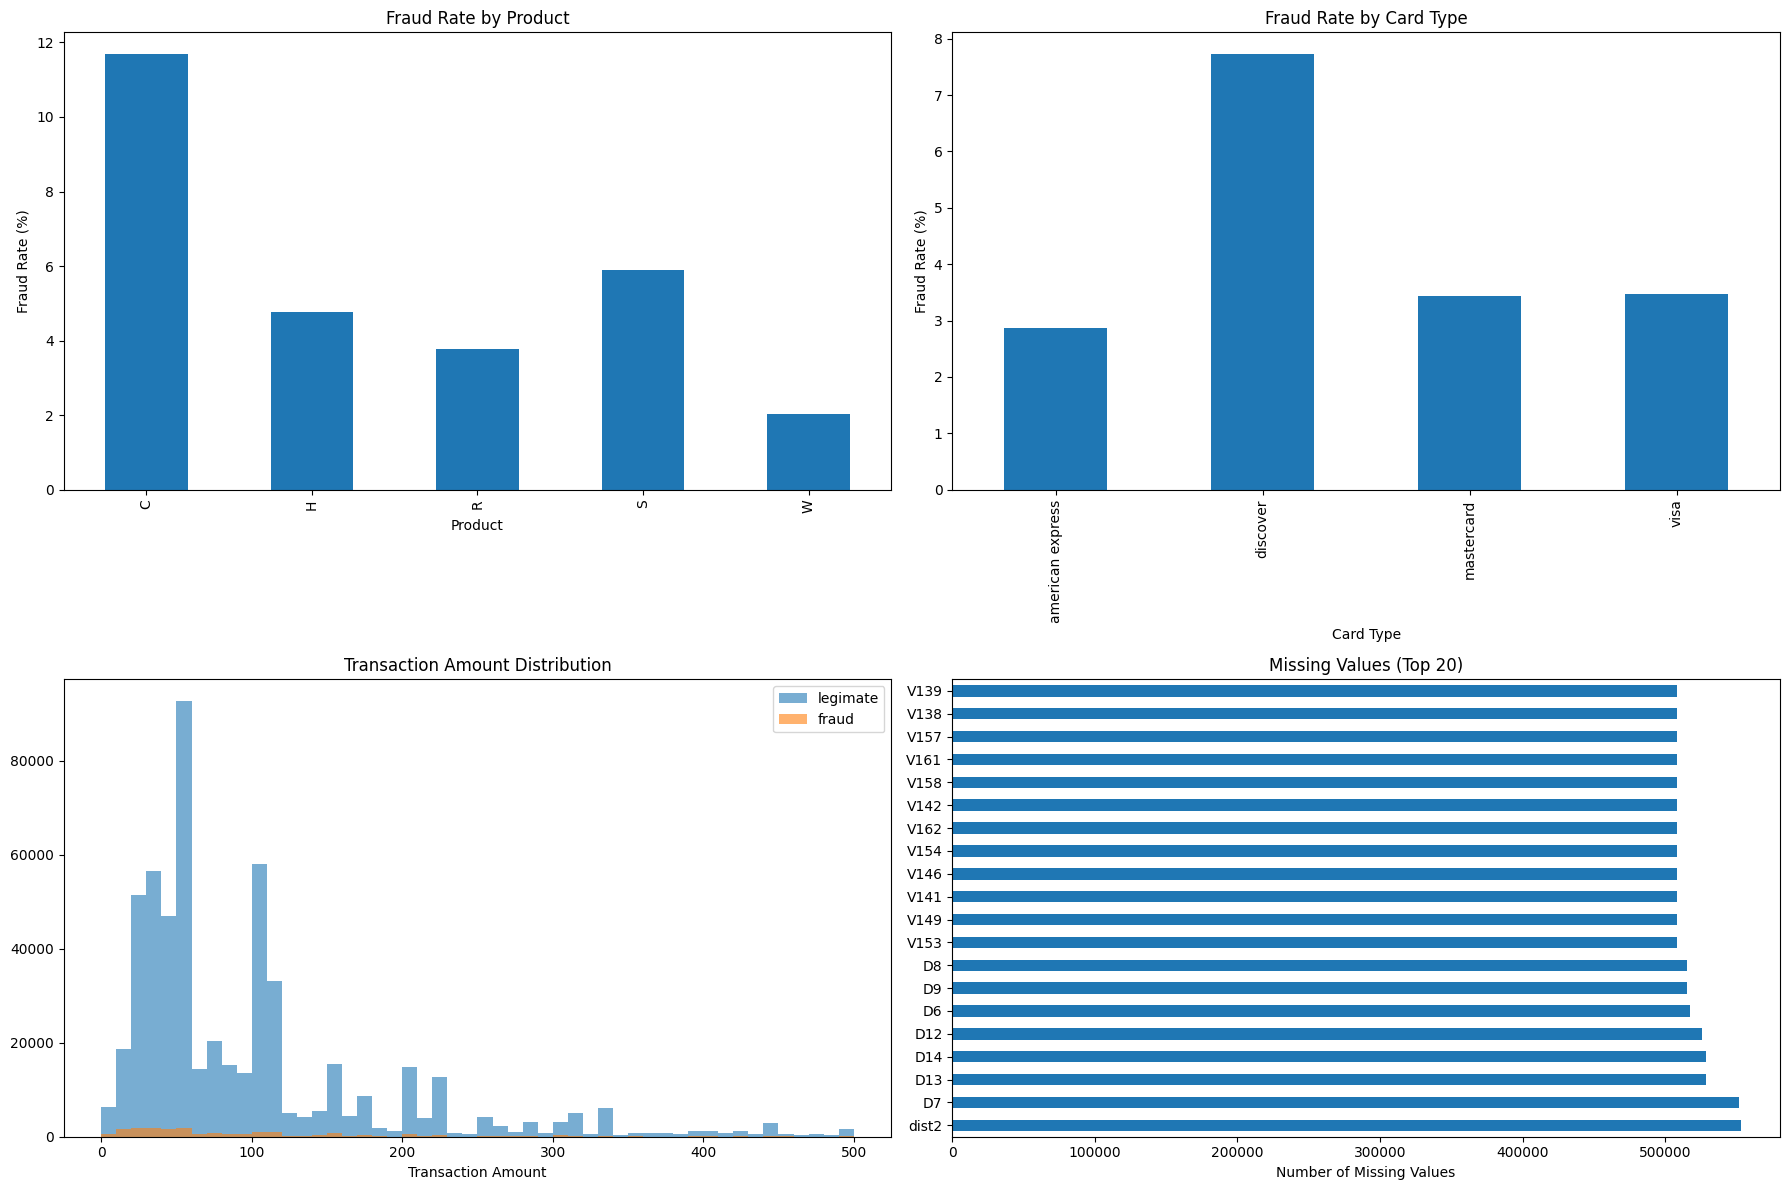

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(18,12))
axes = axes.flatten()

# Fraud rate by product
fraud_by_product = transaction_data.groupby('ProductCD')['isFraud'].mean()*100
fraud_by_product.plot(kind = 'bar', ax = axes[0])
axes[0].set_title('Fraud Rate by Product')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Fraud Rate (%)')

# Fraud by card type
fraud_by_card = transaction_data.groupby('card4')['isFraud'].mean() * 100
fraud_by_card.plot(kind = 'bar', ax = axes[1])
axes[1].set_title('Fraud Rate by Card Type')
axes[1].set_xlabel('Card Type')
axes[1].set_ylabel('Fraud Rate (%)')

# Transaction amount distribution
axes[2].hist(transaction_data[transaction_data['isFraud']== 0]['TransactionAmt'], bins = 50, alpha = 0.6, label = 'legimate', range = (0, 500))
axes[2].hist(transaction_data[transaction_data['isFraud'] == 1]['TransactionAmt'], bins = 50, alpha = 0.6, label = 'fraud', range = (0, 500))
axes[2].set_title('Transaction Amount Distribution')
axes[2].set_xlabel('Transaction Amount')
axes[2].legend()

# Missing values (top 20)
missing = transaction_data.isnull().sum().sort_values(ascending = False).head(20)
missing.plot(kind = 'barh', ax = axes[3])
axes[3].set_title('Missing Values (Top 20)')
axes[3].set_xlabel('Number of Missing Values')

plt.tight_layout()
plt.show()

# **Time Based Analysis**

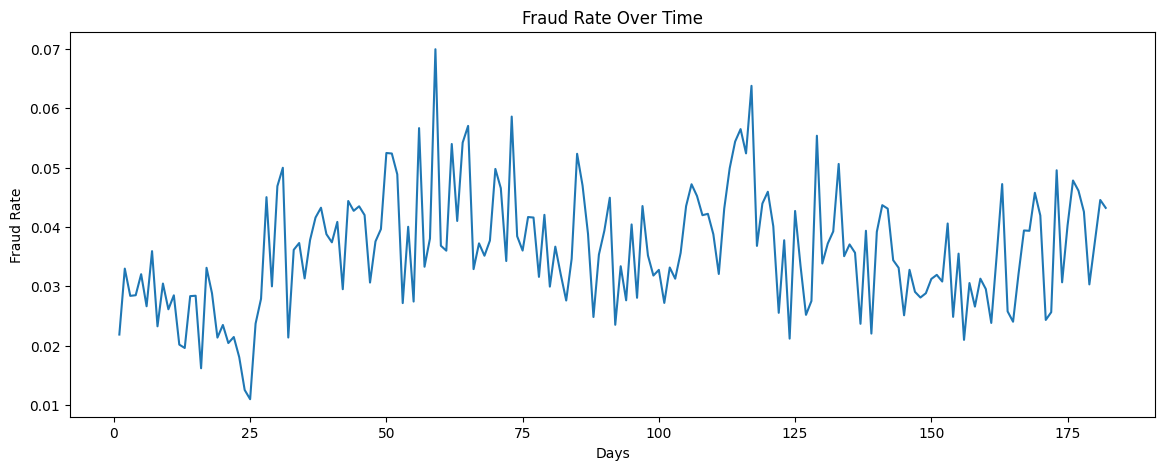

In [ ]:
# Converting TransactionDT to hours for easier analysis
transaction_data['TransactionDT_hours'] = transaction_data['TransactionDT'] / 3600
transaction_data['TransactionDT_days'] = transaction_data['TransactionDT'] / (3600 * 24)

# Fraud over time
plt.figure(figsize=(14, 5))
transaction_data.groupby(transaction_data['TransactionDT_days'].astype(int))['isFraud'].mean().plot()
plt.title('Fraud Rate Over Time')
plt.xlabel('Days')
plt.ylabel('Fraud Rate')
plt.show()

# **Merging Identity data to transaction data**

In [ ]:
identity_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_identity.csv.zip')

In [ ]:
identity_data.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [ ]:
print('-------IDENTITY DATA---------')
print(f'Shape: {identity_data.shape}')
print(f'Columns: {identity_data.columns.tolist()}')


-------IDENTITY DATA---------
Shape: (144233, 41)
Columns: ['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [ ]:
df = transaction_data.merge(identity_data, on = 'TransactionID', how = 'left')
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
print('-------MERGED DATA---------')
print(f'Shape: {df.shape}')
print(f'\nDEVICE INFO (where available)')
print(df.groupby('DeviceInfo')['isFraud'].agg(['mean','count']))

-------MERGED DATA---------
Shape: (590540, 436)

DEVICE INFO (where available)
                mean  count
DeviceInfo                 
0PAJ5            0.0      1
0PJA2            0.0      1
0PM92            0.5      4
1016S            0.0      1
2PQ93            0.0      1
...              ...    ...
verykools5004    0.0      2
verykools5034    0.0      1
verykools5035    0.0      1
vivo             0.0      5
xs-Z47b7VqTMxs   0.0      1

[1786 rows x 2 columns]


In [ ]:
df['isFraud'].value_counts(normalize=True) * 100


,proportion
isFraud,
0,96.500999
1,3.499001


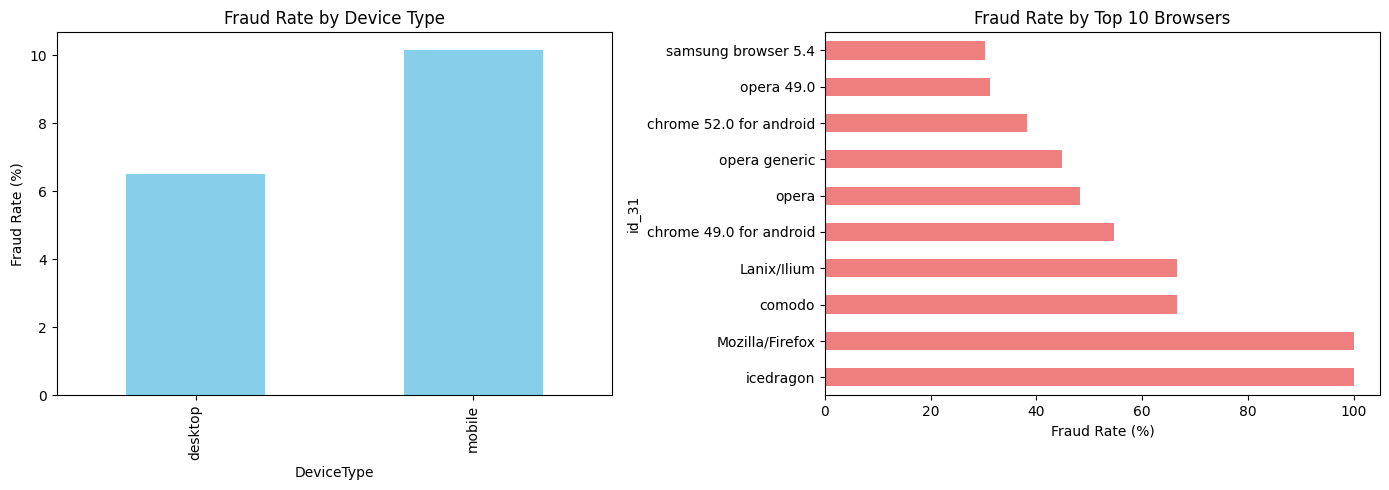

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device Type
if 'DeviceType' in df.columns:
    device_fraud = df.groupby('DeviceType')['isFraud'].mean() * 100
    device_fraud.plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Fraud Rate by Device Type')
    axes[0].set_ylabel('Fraud Rate (%)')

# Browser (id_31)
if 'id_31' in df.columns:
    browser_fraud = df.groupby('id_31')['isFraud'].mean().sort_values(ascending=False).head(10) * 100
    browser_fraud.plot(kind='barh', ax=axes[1], color='lightcoral')
    axes[1].set_title('Fraud Rate by Top 10 Browsers')
    axes[1].set_xlabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

# **Surface Level Observations of this EDA Notebook**
1)  **Low Fraud Rate:** Overall, only about **3.5%** of transactions are fraudulent. The vast majority are legitimate.
2)   **Risky Products:** Transactions labeled with Product Code **'C'** are the most risky, with over **11%** being fraud. Product 'W' is the most common but has a low fraud rate.
3)   **Card Types:** **'Discover'** cards have a higher fraud rate (7.7%) compared to Visa or Mastercard (3.4%). American Express is the safest in this dataset.
4)   **Transaction Amounts:** Fraudulent transactions are slightly higher in value on average compared to legitimate ones.
5)   **Device Risk:** Transactions made on **Mobile** devices are more likely to be fraud (10%) compared to **Desktop** computers (6.5%).
6)   **Browser Activity:** Certain uncommon or specific web browsers show extremely high fraud rates, indicating potential automated attacks or specific tools used by fraudsters.
7)   **Missing Data:** A significant amount of information is missing in the dataset.